In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
import pandas as pd

df = pd.read_csv("../data/Global_Superstore2.csv", encoding="latin1")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   Row ID         Order ID  Order Date   Ship Date     Ship Mode Customer ID  \
0   32298   CA-2012-124891  31-07-2012  31-07-2012      Same Day    RH-19495   
1   26341    IN-2013-77878  05-02-2013  07-02-2013  Second Class    JR-16210   
2   25330    IN-2013-71249  17-10-2013  18-10-2013   First Class    CR-12730   
3   13524  ES-2013-1579342  28-01-2013  30-01-2013   First Class    KM-16375   
4   47221     SG-2013-4320  05-11-2013  06-11-2013      Same Day     RH-9495   

      Customer Name      Segment           City            State  ...  \
0       Rick Hansen     Consumer  New York City         New York  ...   
1     Justin Ritter    Corporate     Wollongong  New South Wales  ...   
2      Craig Reiter     Consumer       Brisbane       Queensland  ...   
3  Katherine Murray  Home Office         Berlin           Berlin  ...   
4       Rick Hansen     Consumer          Dakar            Dakar  ...   

         Product ID    Category Sub-Category  \
0  

In [3]:
print("Shape:", df.shape)

Shape: (51290, 24)


In [4]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


Phase 1: Data Understanding
# Retail Performance Analytics System

## Dataset Overview

The Global Superstore dataset contains 51,290 transactions across multiple countries, markets, customer segments, and product categories.

### Business Goal

Provide leadership with insights into:

- Revenue drivers
- Profitability drivers
- Regional performance
- Customer behavior
- Product performance

### Dataset Dimensions

- Rows: 51,290
- Columns: 24

Phase 2: Data Quality Assessment


In [14]:
# Missing values

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Postal Code    41296
dtype: int64

Phase 3: Check Duplicates

In [15]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


Phase 4: Convert Dates

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  str           
 2   Order Date      51290 non-null  datetime64[us]
 3   Ship Date       51290 non-null  datetime64[us]
 4   Ship Mode       51290 non-null  str           
 5   Customer ID     51290 non-null  str           
 6   Customer Name   51290 non-null  str           
 7   Segment         51290 non-null  str           
 8   City            51290 non-null  str           
 9   State           51290 non-null  str           
 10  Country         51290 non-null  str           
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  str           
 13  Region          51290 non-null  str           
 14  Product ID      51290 non-null  str           
 15  Category     

Phase 5: Business Metrics

In [17]:
print("Total Revenue:", round(df['Sales'].sum(), 2))
print("Total Profit:", round(df['Profit'].sum(), 2))
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())

Total Revenue: 12642501.91
Total Profit: 1467457.29
Total Orders: 25035
Total Customers: 1590


Phase 6:Data Profiling Section

In [18]:
df[['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping Cost']].describe()

,Sales,Profit,Quantity,Discount,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,28.610982,3.476545,0.142908,26.375915
std,487.565361,174.340972,2.278766,0.212280,57.296804
min,0.444000,-6599.978000,1.000000,0.000000,0.000000
25%,30.758625,0.000000,2.000000,0.000000,2.610000
50%,85.053000,9.240000,3.000000,0.000000,7.790000
75%,251.053200,36.810000,5.000000,0.200000,24.450000
max,22638.480000,8399.976000,14.000000,0.850000,933.570000


# Executive Summary (Draft)
Company Performance                                              KPI Value

Revenue	                                                         $12.64 Million
Profit	                                                         $1.47 Million
Orders	                                                         25,035
Customers	                                                     1,590

# Initial Findings

- Strong revenue generation ($12.6M)

- Positive overall profitability ($1.47M)

- No duplicate records

-Dataset appears clean and reliable

Postal Code is missing for many international records (expected because not all countries use postal codes consistently)

Minimum Profit = -$6,599.98

This immediately gives us a business investigation:

Which products, regions, or discounts are causing these losses???

# Business Intelligence Analysis

Market
APAC      3.585744e+06
EU        2.938089e+06
US        2.297201e+06
LATAM     2.164605e+06
EMEA      8.061613e+05
Africa    7.837732e+05
Canada    6.692817e+04
Name: Sales, dtype: float64


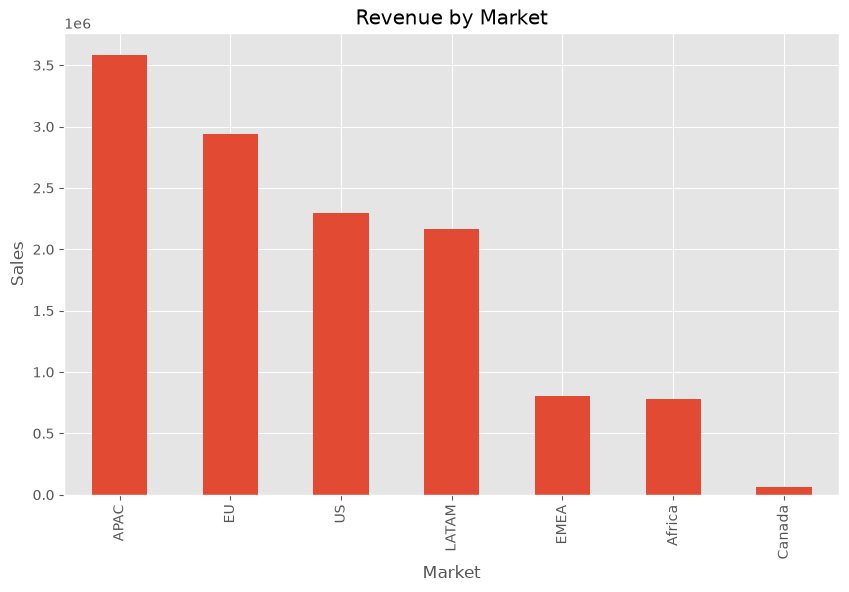

In [21]:
# Analysis 1: Revenue by Market
market_sales = (
    df.groupby('Market')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(market_sales)

plt.figure(figsize=(10,6))
market_sales.plot(kind='bar')
plt.title('Revenue by Market')
plt.ylabel('Sales')
plt.show()

Market
APAC      436000.04900
EU        372829.74150
US        286397.02170
LATAM     221643.48708
Africa     88871.63100
EMEA       43897.97100
Canada     17817.39000
Name: Profit, dtype: float64


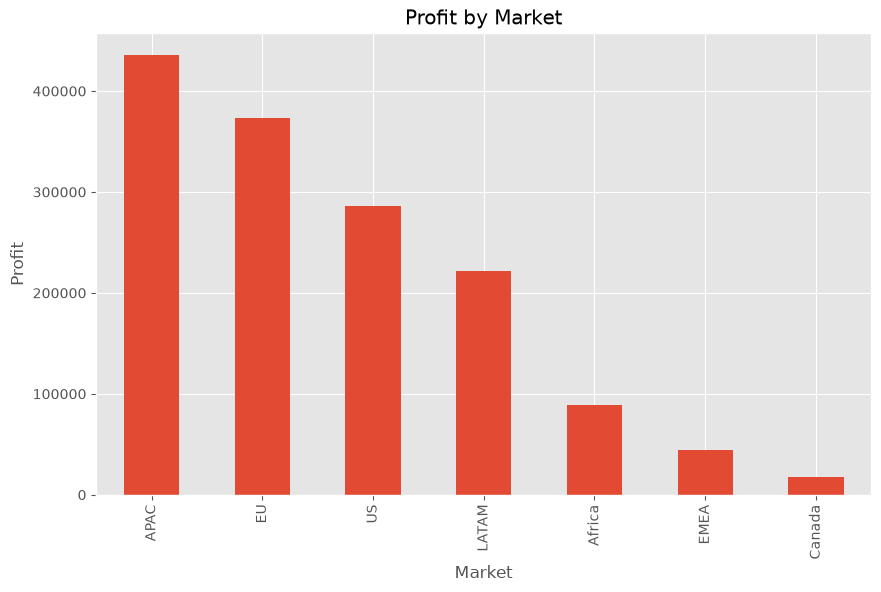

In [22]:
#Analysis 2: Profit by Market

market_profit = (
    df.groupby('Market')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(market_profit)

plt.figure(figsize=(10,6))
market_profit.plot(kind='bar')
plt.title('Profit by Market')
plt.ylabel('Profit')
plt.show()

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64


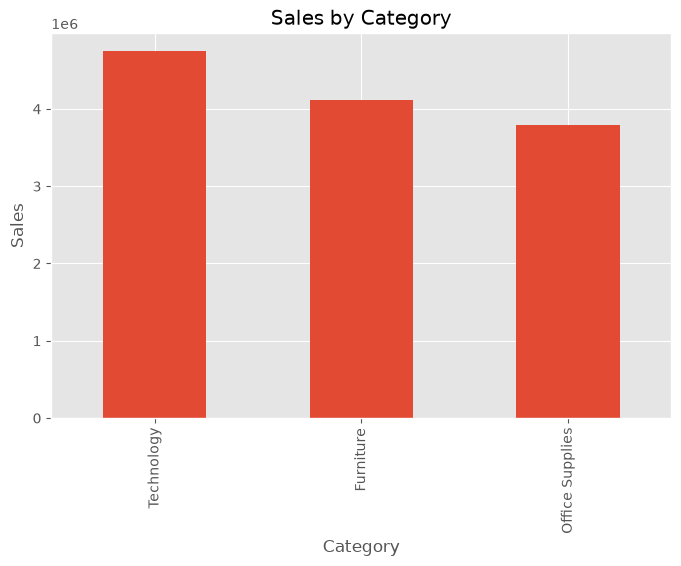

In [23]:
# Analysis 3: Top Product Categories
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64


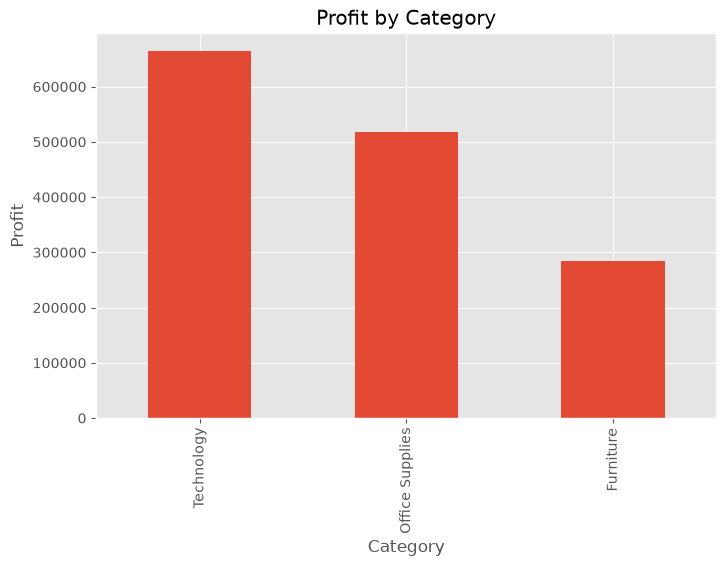

In [24]:
#Analysis 4: Category Profitability

category_profit = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(category_profit)

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.ylabel('Profit')
plt.show()

In [25]:
#Analysis 5: Customer Segment Analysis
segment_analysis = (
    df.groupby('Segment')
      .agg({
          'Sales':'sum',
          'Profit':'sum',
          'Customer ID':'nunique'
      })
)

print(segment_analysis)

                    Sales        Profit  Customer ID
Segment                                             
Consumer     6.507949e+06  749239.78206          818
Corporate    3.824698e+06  441208.32866          476
Home Office  2.309855e+06  277009.18056          296


In [26]:
#Analysis 6: Discount Impact
correlation = df['Discount'].corr(df['Profit'])

print(f"Discount vs Profit Correlation: {correlation:.3f}")

Discount vs Profit Correlation: -0.316


In [28]:
#save images
plt.savefig('../images/revenue_by_market.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [29]:
profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 11.61%


# Key Business Findings
## 1. APAC is the strongest market
Market	Revenue
APAC	$3.59M
EU	$2.94M
US	$2.30M

# APAC generates:

Highest revenue
Highest profit

# Recommendation:

Increase investment in APAC through inventory expansion, marketing campaigns, and customer acquisition initiatives.

## 2. Technology is the superstar category
Category	Revenue
Technology	$4.74M
Furniture	$4.11M
Office Supplies	$3.79M

But the important part is profitability:

Category	Profit
Technology	$663K
Office Supplies	$518K
Furniture	$285K

Technology produces:

Highest revenue
Highest profit


3. Furniture has a problem

Revenue:                                                                       $4.11M


Profit:                                                                        $285K



Compare to:

Technology:
Revenue = $4.74M
Profit = $663K

This suggests:

High operating costs
Heavy discounting
Shipping inefficiencies

We'll investigate this further.

## 4. Consumer Segment Dominates
Segment	Revenue
Consumer	                                                                  $6.51M
Corporate	                                                                  $3.82M
Home Office	                                                                  $2.31M

Profit:

Segment	Profit
Consumer	                                                                  $749K
Corporate	                                                                  $441K
Home Office                                                                   $277K

Recommendation:

Consumer customers should remain the primary growth segment.

5. Discounts Are Hurting Profitability

This is probably the most important finding.

Correlation = -0.316

Meaning:

As discounts increase:

Profit decreases

Report:

Analysis identified a moderate negative relationship between discount levels and profitability, indicating that aggressive discounting may be reducing overall business performance.

That sentence sounds like something from a consulting engagement.

Identify the biggest loss-makers.

In [30]:
worst_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values()
      .head(10)
)

worst_products

Product Name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: Profit, dtype: float64

In [31]:
best_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

best_products

Product Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='YearMonth'>

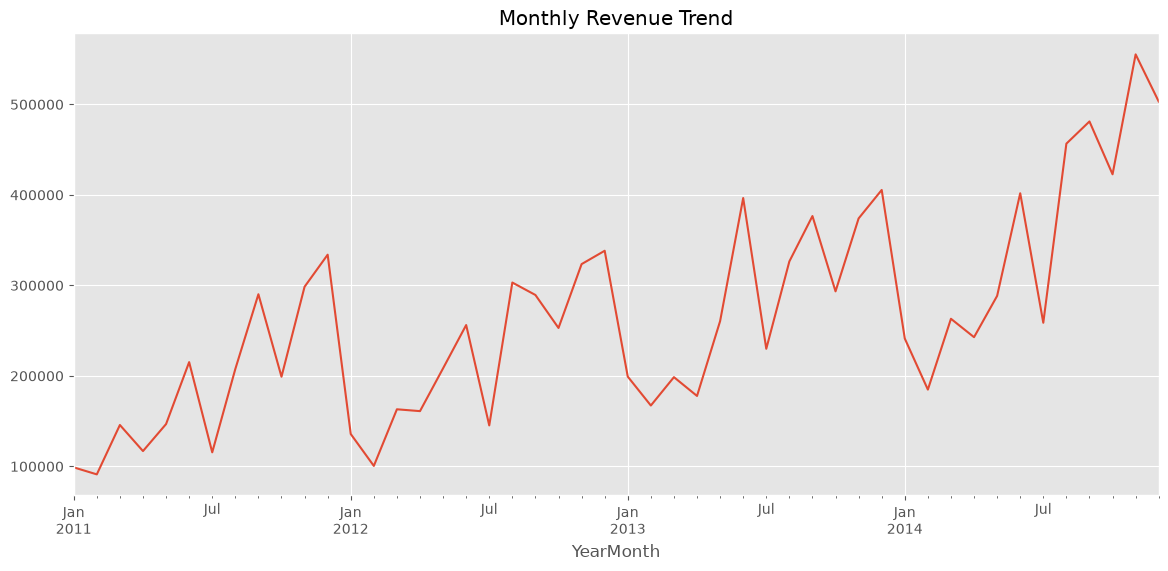

In [32]:
#Monthly Trend Revenue 
df['YearMonth'] = df['Order Date'].dt.to_period('M')

monthly_sales = (
    df.groupby('YearMonth')['Sales']
      .sum()
)

monthly_sales.plot(
    figsize=(14,6),
    title='Monthly Revenue Trend'
)

In [33]:
plt.savefig(
    '../images/monthly_revenue_trend.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

High-Impact Analysis

In [34]:
furniture_analysis = (
    df[df['Category'] == 'Furniture']
    .groupby('Sub-Category')
    .agg({
        'Sales':'sum',
        'Profit':'sum'
    })
    .sort_values('Profit')
)

furniture_analysis

,Sales,Profit
Sub-Category,,
Tables,7.570419e+05,-64083.3887
Furnishings,3.855783e+05,46967.4255
Chairs,1.501682e+06,140396.2675
Bookcases,1.466572e+06,161924.4195


In [35]:
ship_mode_analysis = (
    df.groupby('Ship Mode')
    .agg({
        'Sales':'sum',
        'Profit':'sum',
        'Shipping Cost':'mean'
    })
)

ship_mode_analysis

,Sales,Profit,Shipping Cost
Ship Mode,,,
First Class,1.830976e+06,208104.67520,41.053065
Same Day,6.672020e+05,76173.06780,42.937453
Second Class,2.565672e+06,292583.52708,30.469747
Standard Class,7.578652e+06,890596.02120,19.971755


In [36]:
priority_analysis = (
    df.groupby('Order Priority')
    .agg({
        'Sales':'sum',
        'Profit':'sum'
    })
)

priority_analysis

,Sales,Profit
Order Priority,,
Critical,9.862355e+05,124224.16428
High,3.807548e+06,420373.51340
Low,5.678259e+05,58655.85098
Medium,7.280892e+06,864203.76262


In [37]:
country_sales = (
    df.groupby('Country')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United States     2.297201e+06
Australia         9.252359e+05
France            8.589311e+05
China             7.005620e+05
Germany           6.288400e+05
Mexico            6.225906e+05
India             5.896501e+05
United Kingdom    5.285763e+05
Indonesia         4.048875e+05
Brazil            3.611064e+05
Name: Sales, dtype: float64

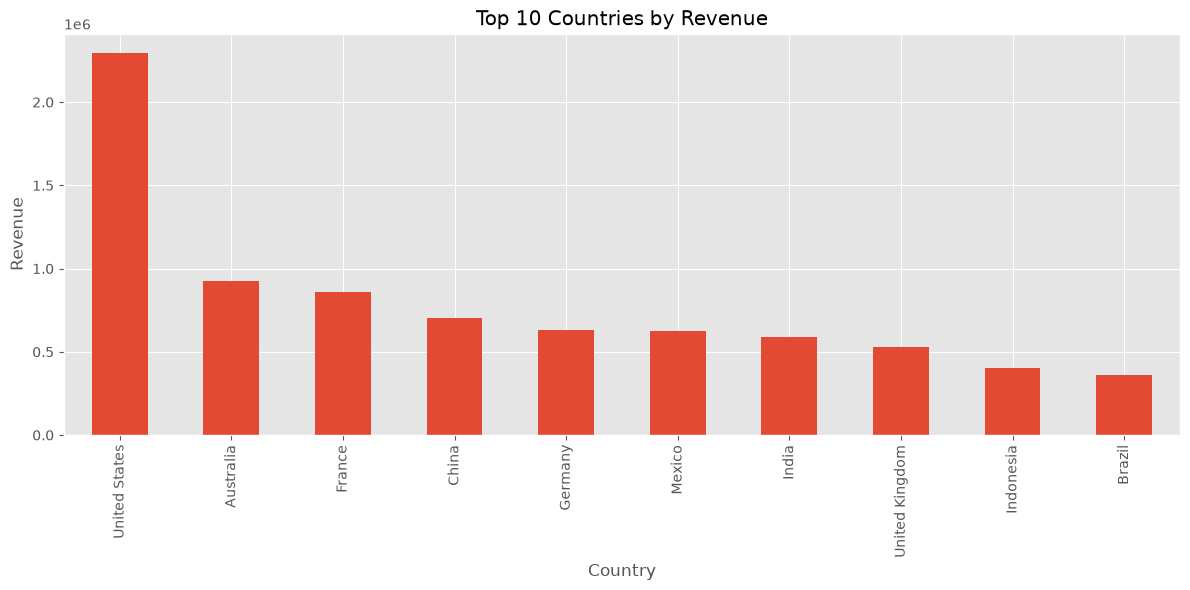

In [38]:
plt.figure(figsize=(12,6))

country_sales.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue')
plt.tight_layout()

plt.savefig(
    '../images/top_countries_revenue.png',
    bbox_inches='tight'
)

plt.show()

In [39]:
category_margin = (
    df.groupby('Category')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
)

category_margin['Profit Margin %'] = (
    category_margin['Profit'] /
    category_margin['Sales']
) * 100

category_margin

,Sales,Profit,Profit Margin %
Category,,,
Furniture,4.110874e+06,285204.72380,6.937812
Office Supplies,3.787070e+06,518473.83430,13.690632
Technology,4.744557e+06,663778.73318,13.990319
